In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
from sylphy.reductions import reduce_dimensionality

In [ ]:
df_data = pd.read_csv("../../processed_dataset/encoded_data/esm2_t6_8M_UR50D/full_data.csv")
df_data = df_data.drop(columns=["sequence"])
label_data = df_data["label"].values
df_data_values = df_data.drop(columns=["label"]).values

,p_0,p_1,p_2,p_3,p_4,p_5,p_6,p_7,p_8,p_9,...,p_311,p_312,p_313,p_314,p_315,p_316,p_317,p_318,p_319,label
0,-0.104359,0.003477,0.011733,0.227170,0.108094,0.017254,0.048430,-0.171665,-0.132107,-0.048827,...,0.168845,-0.072621,-0.021528,0.133301,-0.124900,-0.108684,0.107795,0.083771,0.099923,1
1,-0.005945,-0.038044,0.234305,0.102198,0.209215,-0.089085,0.121648,-0.044797,-0.061557,-0.007792,...,0.138521,-0.166572,0.279429,0.110693,-0.270329,-0.046032,0.327304,0.095373,-0.006549,1
2,-0.023066,-0.090399,0.233495,-0.002653,0.148485,-0.123516,0.072298,-0.062177,-0.182419,0.051194,...,-0.058521,-0.131631,0.329936,-0.010560,-0.228847,-0.044402,0.470133,0.065090,-0.085251,1
3,-0.223800,-0.067328,0.304385,0.087471,0.181850,-0.171054,0.132453,-0.018468,-0.282086,0.192621,...,0.064425,-0.145082,0.432519,0.042665,-0.218214,-0.084764,0.602482,0.097752,0.039144,1
4,0.063286,0.017615,0.053684,0.031515,0.009794,-0.086511,-0.108901,0.019776,-0.141548,-0.285111,...,-0.065966,-0.200351,0.186523,0.002346,-0.053331,0.075978,0.198619,-0.017900,-0.004732,1


In [12]:
model, umap_reduced = reduce_dimensionality(
    method="umap",  # pca, truncated_svd, umap, tsne, isomap, etc.
    dataset=df_data_values,
    n_components=2,
    random_state=42,
    return_type="pandas"  # numpy or pandas
)

In [15]:
model, tsne_reduced = reduce_dimensionality(
    method="tsne",  # pca, truncated_svd, umap, tsne, isomap, etc.
    dataset=df_data_values,
    n_components=2,
    random_state=42,
    return_type="pandas"  # numpy or pandas
)

In [13]:
model, pca_reduced = reduce_dimensionality(
    method="pca",  # pca, truncated_svd, umap, tsne, isomap, etc.
    dataset=df_data_values,
    n_components=2,
    random_state=42,
    return_type="pandas"  # numpy or pandas
)

In [16]:
umap_reduced["label"] = label_data
tsne_reduced["label"] = label_data
pca_reduced["label"] = label_data

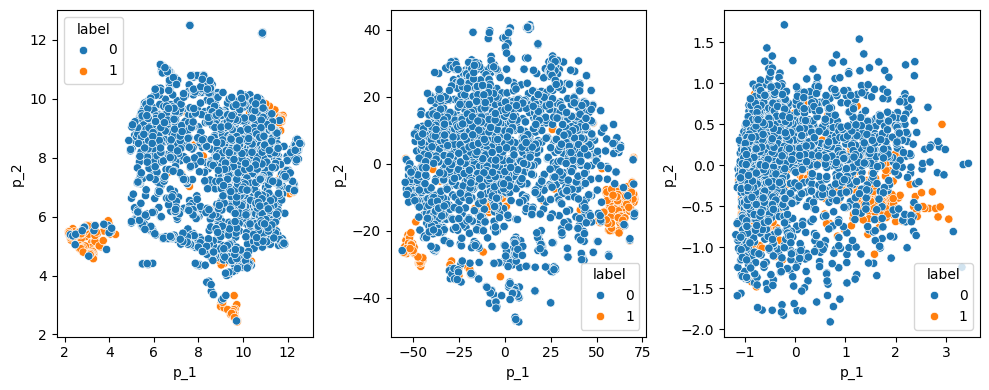

In [18]:
_, axis = plt.subplots(1, 3, figsize=(10, 4))

sns.scatterplot(ax=axis[0], data=umap_reduced, x="p_1", y="p_2", hue="label")
sns.scatterplot(ax=axis[1], data=tsne_reduced, x="p_1", y="p_2", hue="label")
sns.scatterplot(ax=axis[2], data=pca_reduced, x="p_1", y="p_2", hue="label")

plt.tight_layout()